<a href="https://colab.research.google.com/github/Bhanu-Jakka/ML_Project/blob/main/EDA_IPL_MatchPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [27]:
#Load data
# If your files are zipped, unzip first (skip if already .csv in Colab root)
# import zipfile
# with zipfile.ZipFile("deliveries.csv.zip", "r") as z:
#     z.extractall(".")

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

Matches: (1095, 20)
Deliveries: (260920, 17)


In [3]:
#Basic structure of both datasets
print("=== MATCHES ===")
print(matches.columns.tolist())
print(matches.dtypes)
print(matches.head())

print("\n=== DELIVERIES ===")
print(deliveries.columns.tolist())
print(deliveries.dtypes)
print(deliveries.head())

=== MATCHES ===
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19   

In [5]:
#Describe / info
matches.describe(include='all')
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [6]:
#Missing values
print("Matches missing values:\n", matches.isnull().sum())
print("\nDeliveries missing % :\n", (deliveries.isnull().sum() / len(deliveries) * 100).sort_values(ascending=False))

Matches missing values:
 id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Deliveries missing % :
 fielder             96.414993
dismissal_kind      95.036793
player_dismissed    95.036793
extras_type         94.586463
match_id             0.000000
inning               0.000000
batting_team         0.000000
bowling_team         0.000000
over                 0.000000
non_striker          0.000000
bowler               0.000000
batter               0.000000
ball                 0.000000
total_runs           0.000000
extra_runs           0.000000
batsman

In [7]:
#Duplicates
print("Duplicate rows in matches:", matches.duplicated().sum())
print("Duplicate rows in deliveries:", deliveries.duplicated().sum())

Duplicate rows in matches: 0
Duplicate rows in deliveries: 0


In [8]:
#Clean up team names
rename_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings'
}

for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(rename_map)

for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(rename_map)

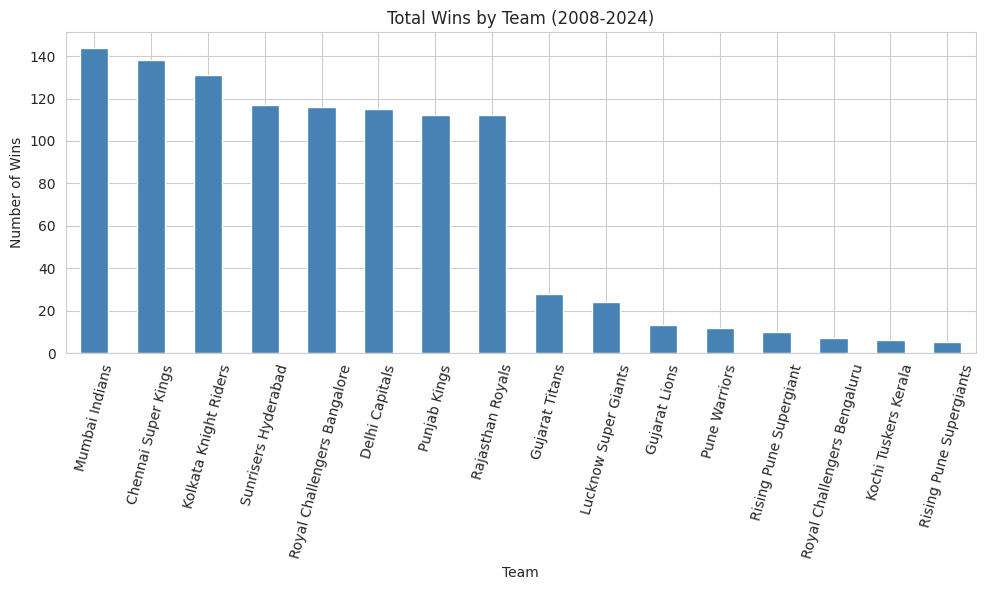

In [9]:
#Wins by team
plt.figure(figsize=(10,6))
matches['winner'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Total Wins by Team (2008-2024)')
plt.xlabel('Team'); plt.ylabel('Number of Wins')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

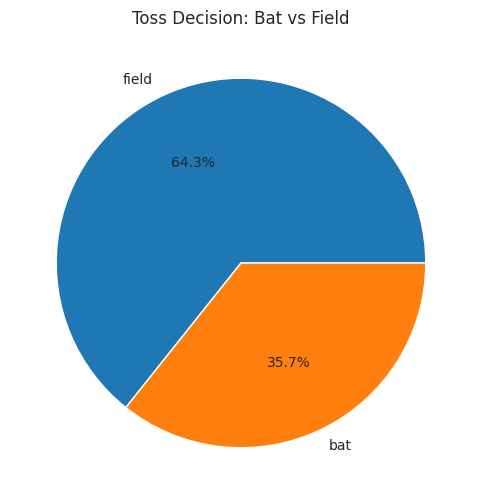

In [10]:
#Toss decision split
matches['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Toss Decision: Bat vs Field')
plt.ylabel('')
plt.show()

In [11]:
#Does winning toss mean winning match?
matches['toss_winner_match_winner'] = matches['toss_winner'] == matches['winner']
print(matches['toss_winner_match_winner'].value_counts(normalize=True) * 100)

toss_winner_match_winner
True     50.593607
False    49.406393
Name: proportion, dtype: float64


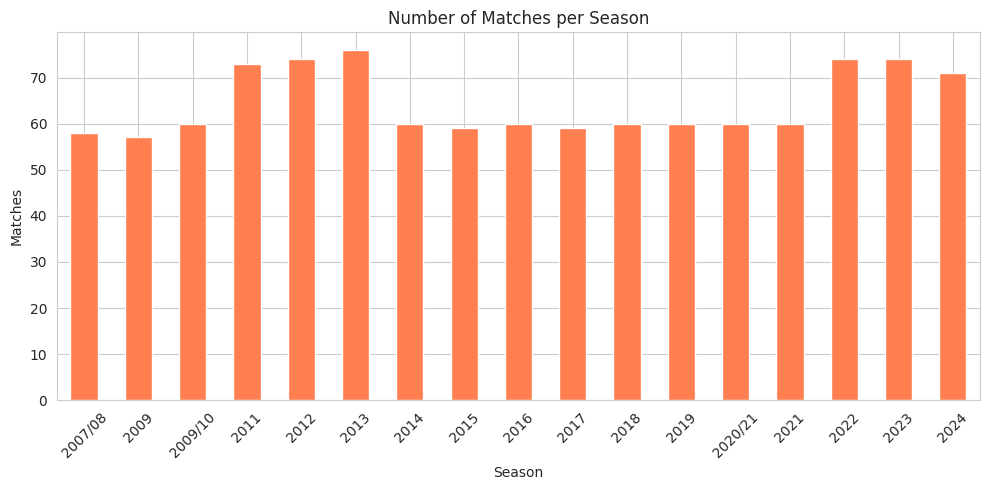

In [12]:
#Matches per season
plt.figure(figsize=(10,5))
matches['season'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Number of Matches per Season')
plt.xlabel('Season'); plt.ylabel('Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

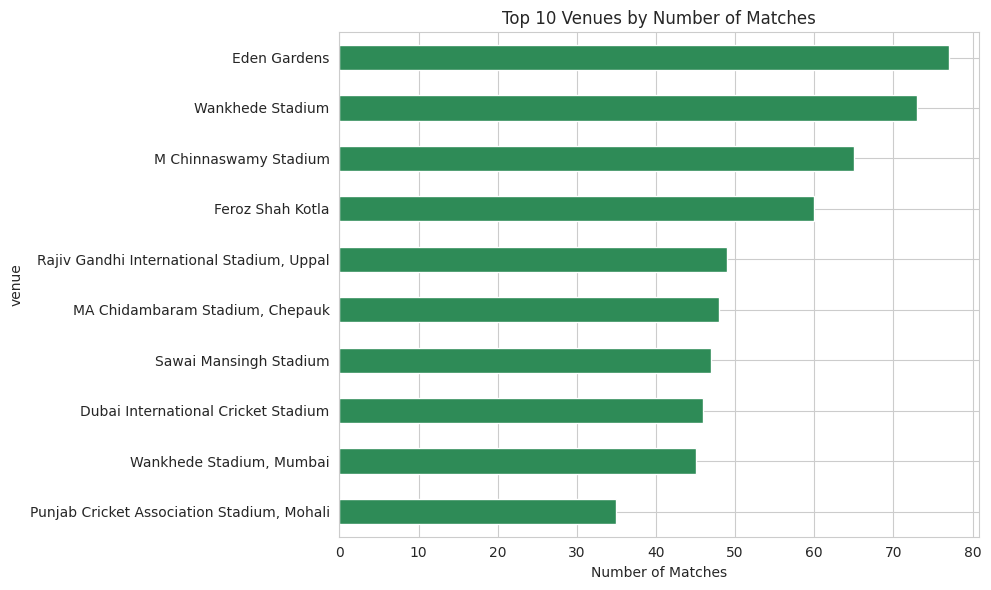

city
Mumbai           173
Kolkata           93
Delhi             90
Chennai           85
Hyderabad         77
Bangalore         65
Chandigarh        61
Jaipur            57
Pune              51
Abu Dhabi         37
Ahmedabad         36
Bengaluru         29
Visakhapatnam     15
Durban            15
Lucknow           14
Name: count, dtype: int64


In [13]:
# Top venues & host cities
plt.figure(figsize=(10,6))
matches['venue'].value_counts().head(10).plot(kind='barh', color='seagreen')
plt.title('Top 10 Venues by Number of Matches')
plt.xlabel('Number of Matches')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(matches['city'].value_counts().head(15))

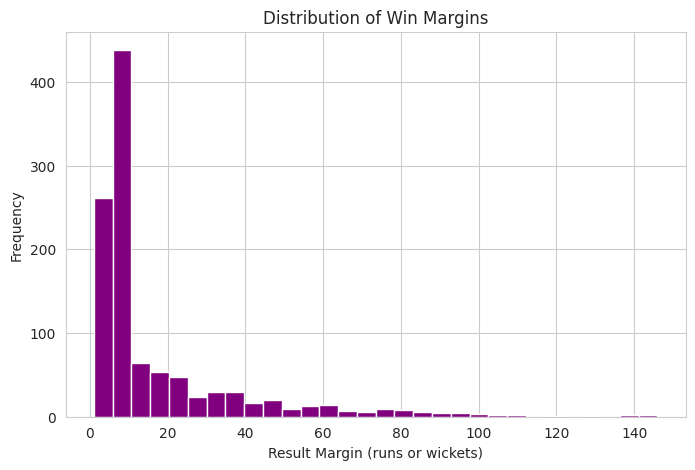

In [14]:
#Win margin distribution
plt.figure(figsize=(8,5))
matches['result_margin'].dropna().plot(kind='hist', bins=30, color='purple')
plt.title('Distribution of Win Margins')
plt.xlabel('Result Margin (runs or wickets)')
plt.show()

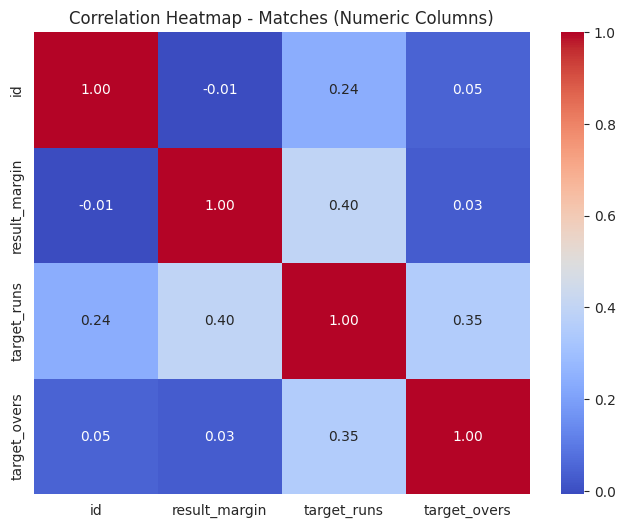

In [15]:
#Correlation heatmap (matches numeric cols)
numeric_cols = matches.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap - Matches (Numeric Columns)')
plt.show()

In [16]:
# Runs / extras / wickets totals (deliveries)
total_runs = deliveries['total_runs'].sum()
batsman_runs = deliveries['batsman_runs'].sum()
extra_runs = deliveries['extra_runs'].sum()
total_wickets = deliveries['is_wicket'].sum()

print("Total Runs:", total_runs)
print("Batsman Runs:", batsman_runs)
print("Extra Runs:", extra_runs)
print("Total Wickets:", total_wickets)

Total Runs: 347756
Batsman Runs: 330064
Extra Runs: 17692
Total Wickets: 12950


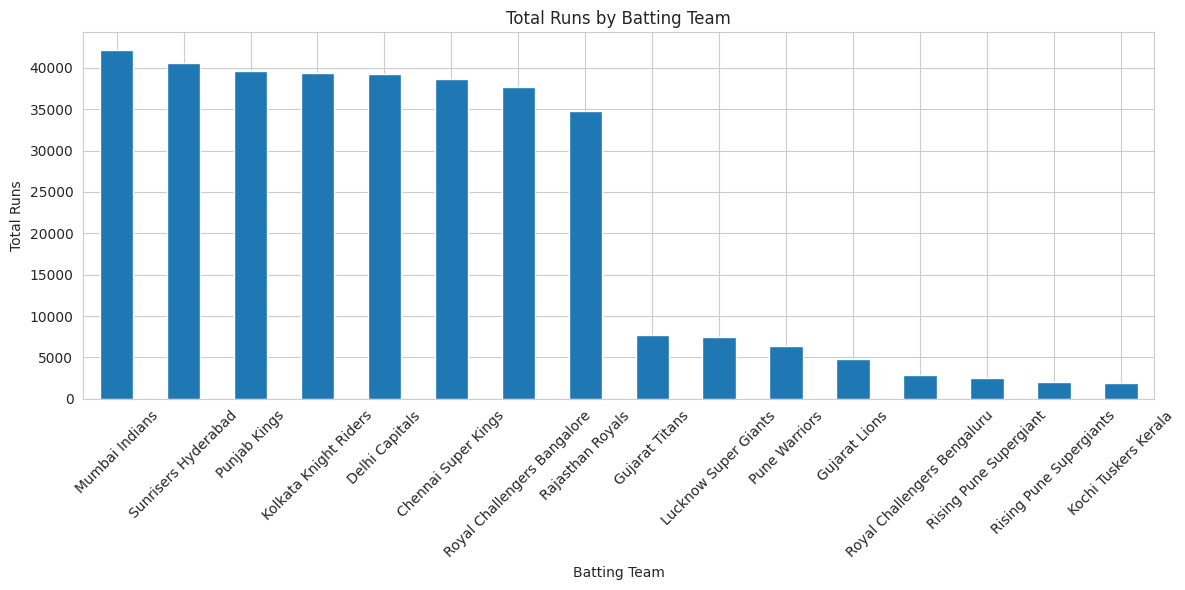

In [17]:
# Runs by batting team
team_runs = deliveries.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
team_runs.plot(kind='bar')
plt.title('Total Runs by Batting Team')
plt.xlabel('Batting Team'); plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

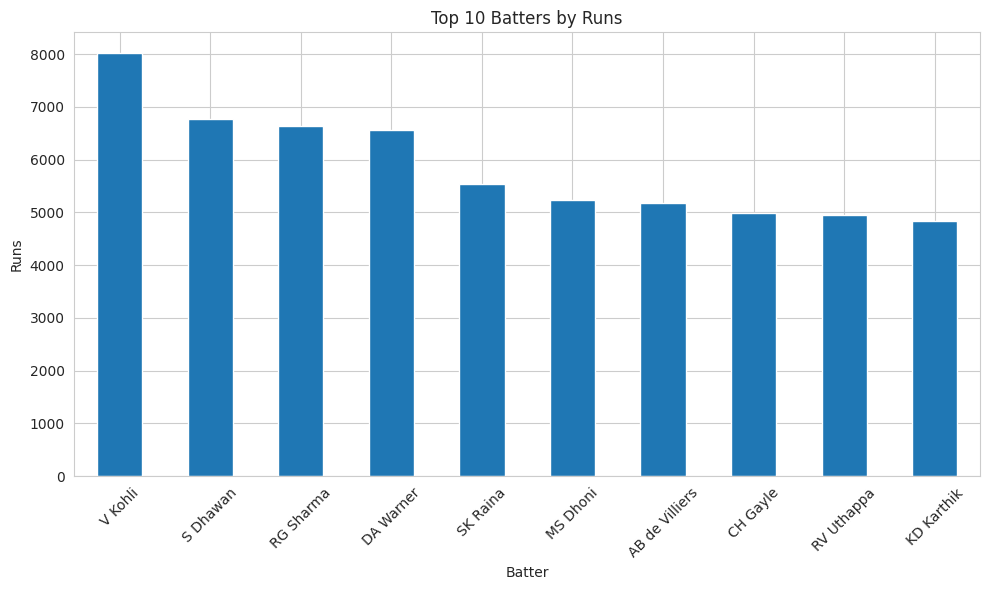

In [18]:
# Top batters
top_batters = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_batters.plot(kind='bar')
plt.title('Top 10 Batters by Runs')
plt.xlabel('Batter'); plt.ylabel('Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

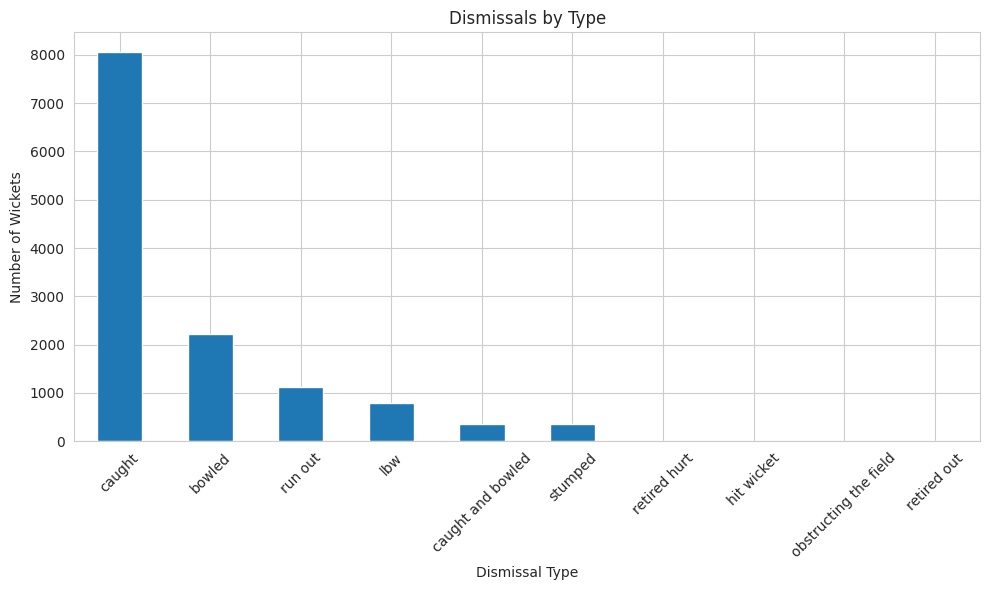

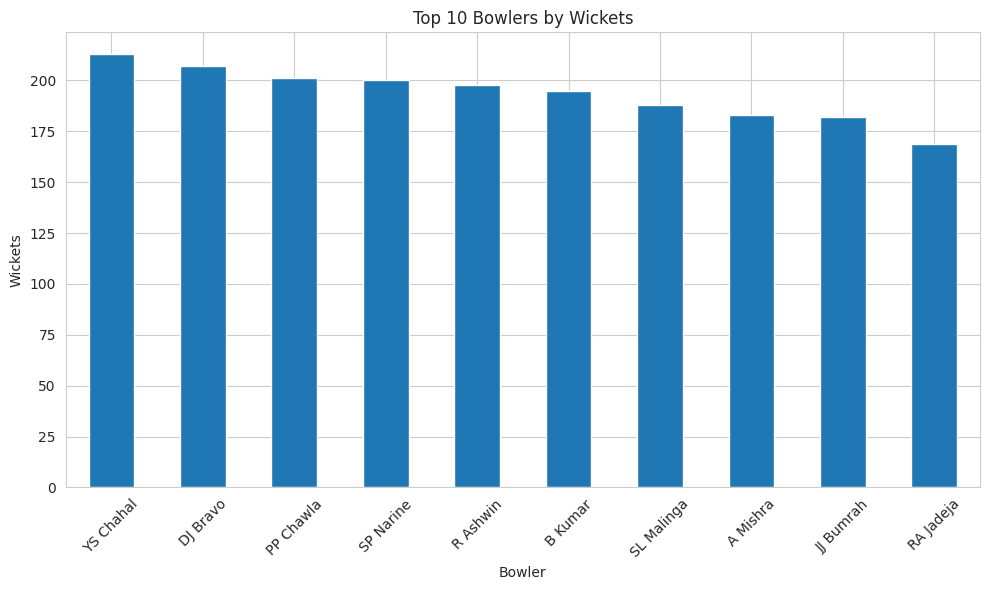

In [19]:
# Dismissal types & top bowlers
dismissal_types = deliveries['dismissal_kind'].value_counts()

plt.figure(figsize=(10,6))
dismissal_types.plot(kind='bar')
plt.title('Dismissals by Type')
plt.xlabel('Dismissal Type'); plt.ylabel('Number of Wickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_bowlers = (deliveries[deliveries['is_wicket']==1]
               .groupby('bowler')['is_wicket'].sum()
               .sort_values(ascending=False).head(10))

plt.figure(figsize=(10,6))
top_bowlers.plot(kind='bar')
plt.title('Top 10 Bowlers by Wickets')
plt.xlabel('Bowler'); plt.ylabel('Wickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

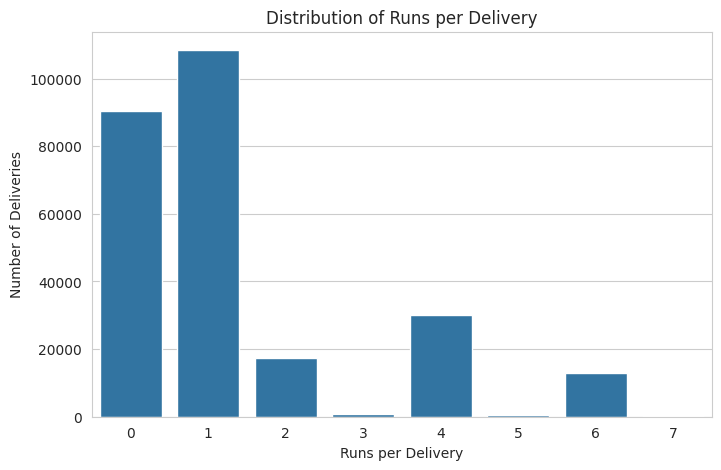

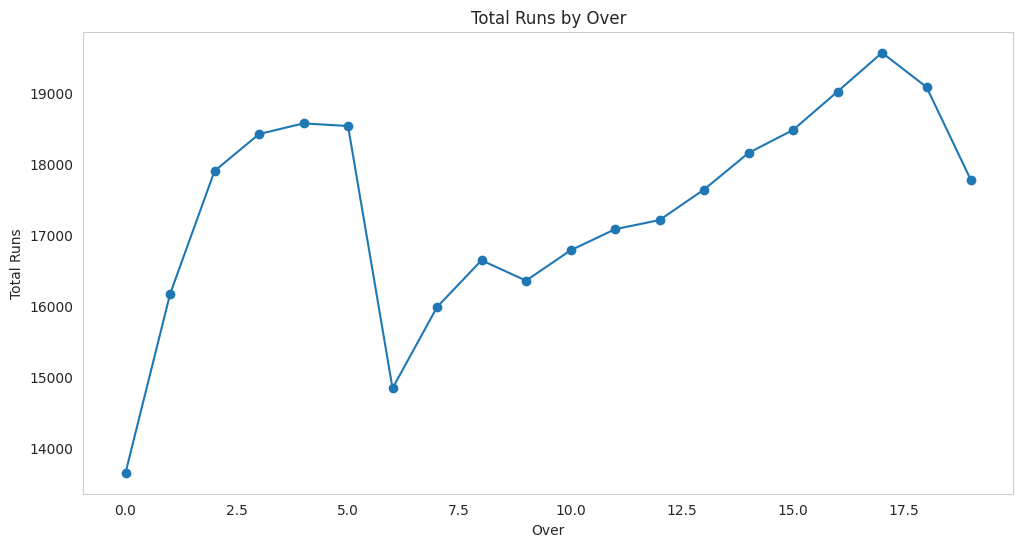

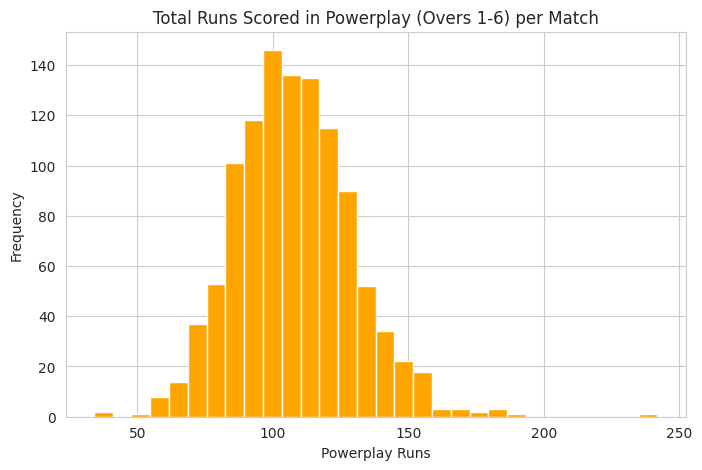

In [20]:
# Runs per delivery & runs by over (powerplay trend)
plt.figure(figsize=(8,5))
sns.countplot(data=deliveries, x='total_runs')
plt.title('Distribution of Runs per Delivery')
plt.xlabel('Runs per Delivery'); plt.ylabel('Number of Deliveries')
plt.show()

runs_by_over = deliveries.groupby('over')['total_runs'].sum()
plt.figure(figsize=(12,6))
runs_by_over.plot(kind='line', marker='o')
plt.title('Total Runs by Over')
plt.xlabel('Over'); plt.ylabel('Total Runs')
plt.grid()
plt.show()

# Powerplay (overs 0-6) total runs per match
powerplay = deliveries[deliveries['over'] <= 6]
powerplay_runs = powerplay.groupby('match_id')['total_runs'].sum()
plt.figure(figsize=(8,5))
powerplay_runs.plot(kind='hist', bins=30, color='orange')
plt.title('Total Runs Scored in Powerplay (Overs 1-6) per Match')
plt.xlabel('Powerplay Runs')
plt.show()

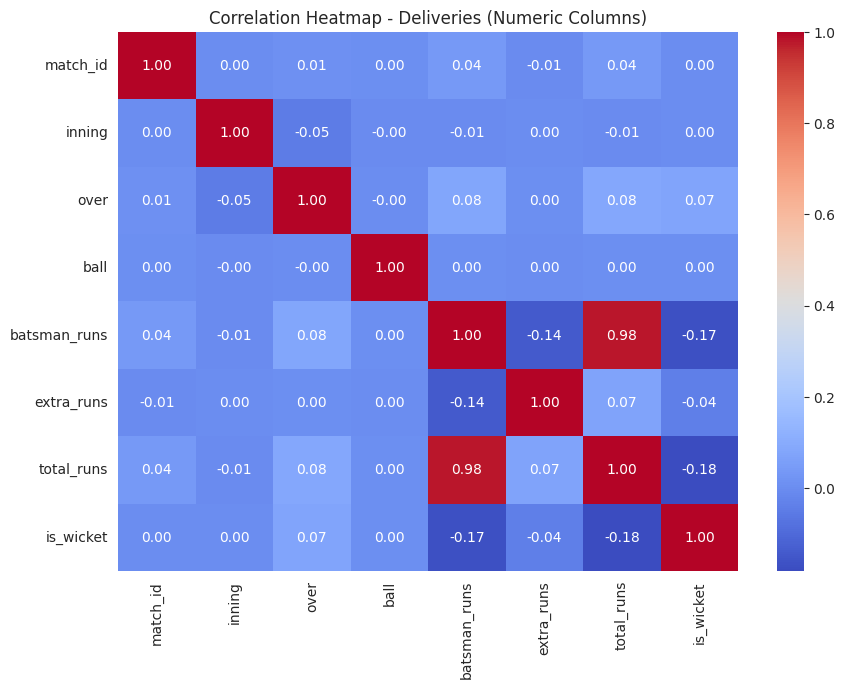

In [21]:
# Correlation heatmap
numeric_df = deliveries.select_dtypes(include='number')
correlation = numeric_df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Deliveries (Numeric Columns)')
plt.show()

In [22]:
# Home vs Away win rate
# Map each team to its "home" city based on most frequent venue city where they played
city_home = matches.melt(id_vars=['city'], value_vars=['team1','team2'], value_name='team') \
                    .groupby('team')['city'].agg(lambda x: x.value_counts().idxmax())

matches['team1_home'] = matches['team1'].map(city_home) == matches['city']
matches['team2_home'] = matches['team2'].map(city_home) == matches['city']

home_wins = matches[(matches['team1_home']) & (matches['winner'] == matches['team1'])].shape[0] + \
            matches[(matches['team2_home']) & (matches['winner'] == matches['team2'])].shape[0]
home_matches = matches['team1_home'].sum() + matches['team2_home'].sum()

print(f"Home win rate: {home_wins/home_matches*100:.2f}%")

Home win rate: 55.01%


In [23]:
#Head-to-head between two teams
def head_to_head(team_a, team_b, matches_df):
    h2h = matches_df[((matches_df['team1']==team_a) & (matches_df['team2']==team_b)) |
                      ((matches_df['team1']==team_b) & (matches_df['team2']==team_a))]
    print(f"{team_a} vs {team_b}: {len(h2h)} matches")
    print(h2h['winner'].value_counts())
    return h2h

_ = head_to_head('Mumbai Indians', 'Chennai Super Kings', matches)

Mumbai Indians vs Chennai Super Kings: 37 matches
winner
Mumbai Indians         20
Chennai Super Kings    17
Name: count, dtype: int64


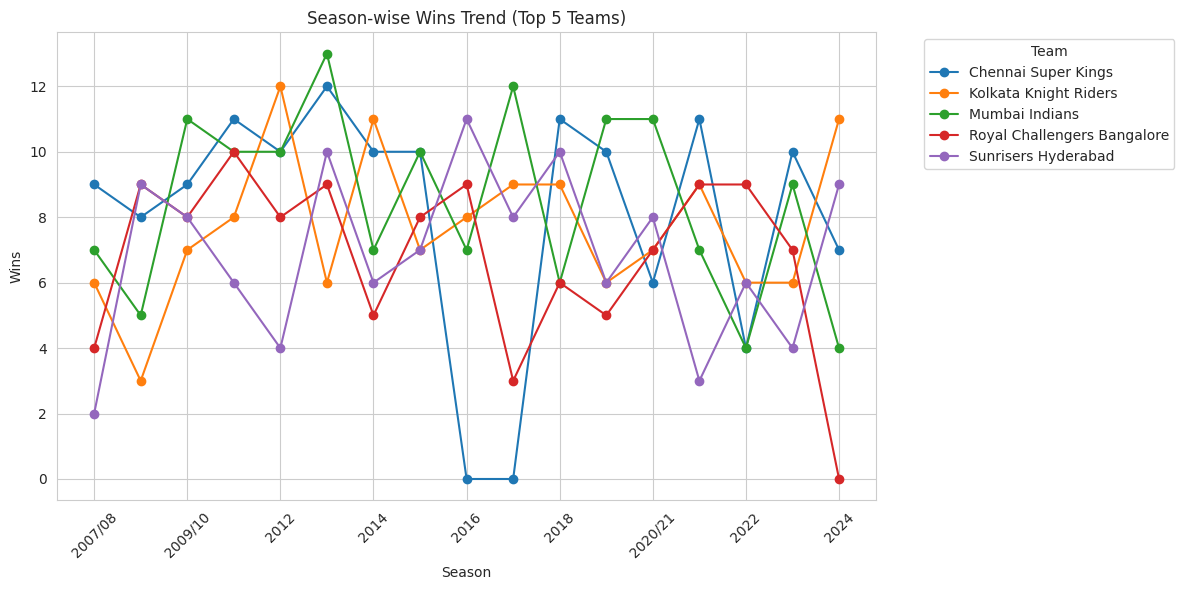

In [24]:
#Season-wise win trend for top teams
top_teams = matches['winner'].value_counts().head(5).index
season_trend = matches[matches['winner'].isin(top_teams)] \
    .groupby(['season','winner']).size().unstack(fill_value=0)

season_trend.plot(kind='line', marker='o', figsize=(12,6))
plt.title('Season-wise Wins Trend (Top 5 Teams)')
plt.xlabel('Season'); plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.legend(title='Team', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

In [25]:
#EDA summary
print("========== EDA SUMMARY ==========")
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("Total Runs:", total_runs)
print("Total Wickets:", total_wickets)
print("Toss winner also match winner (%):", round(matches['toss_winner_match_winner'].mean()*100, 2))
print("Home win rate (%):", round(home_wins/home_matches*100, 2))
print("Top team by wins:", matches['winner'].value_counts().idxmax())

========== EDA SUMMARY ==========
Matches shape: (1095, 23)
Deliveries shape: (260920, 17)
Total Runs: 347756
Total Wickets: 12950
Toss winner also match winner (%): 50.59
Home win rate (%): 55.01
Top team by wins: Mumbai Indians
